# Lab 5, Day 1 — Exploration and Cleaning

Explore, profile, and clean the Titanic dataset, then split it and check your column
groups - no model yet. See `Lab5_Day1_Instructions.md` for the full walkthrough.

This notebook is just a shell: it gives you a place to write and document your work,
but the profiling, the decisions, and the reasoning are yours.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data import load_titanic
from sklearn.model_selection import train_test_split
import joblib

df, source = load_titanic()
print('source:', source)
df.head()


Loaded real Titanic from OpenML  (1309, 14)
source: openml


,Pclass,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Step 1: Load and profile

In [15]:
# TODO: df.info(), df.describe(include='all').T, and missingness percentage per
# column, sorted descending
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Pclass     1309 non-null   int64   
 1   Survived   1309 non-null   int64   
 2   Name       1309 non-null   str     
 3   Sex        1309 non-null   category
 4   Age        1046 non-null   float64 
 5   SibSp      1309 non-null   int64   
 6   Parch      1309 non-null   int64   
 7   Ticket     1309 non-null   str     
 8   Fare       1308 non-null   float64 
 9   Cabin      295 non-null    str     
 10  Embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(2), float64(3), int64(4), str(5)
memory usage: 125.4 KB


In [16]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Pclass,1309.0,NaN,NaN,NaN,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
Survived,1309.0,NaN,NaN,NaN,0.381971,0.486055,0.0,0.0,0.0,1.0,1.0
Name,1309,1307,"Connolly, Miss. Kate",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,1309,2,male,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1046.0,NaN,NaN,NaN,29.881135,14.4135,0.1667,21.0,28.0,39.0,80.0
SibSp,1309.0,NaN,NaN,NaN,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
Parch,1309.0,NaN,NaN,NaN,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
Ticket,1309,929,CA. 2343,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,1308.0,NaN,NaN,NaN,33.295479,51.758668,0.0,7.8958,14.4542,31.275,512.3292
Cabin,295,186,C23 C25 C27,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
print("Missing Value Proportions:")
print()
missing = df.isna().mean().sort_values(ascending=False)

for column, value in missing.items():
    bar_length = 30
    filled = int(value * bar_length)
    bar = "█" * filled + " " * (bar_length - filled)
    
    print(f"{column:<12} [{bar}] {value:.2%}")

Missing Value Proportions:

body         [███████████████████████████   ] 90.76%
Cabin        [███████████████████████       ] 77.46%
boat         [██████████████████            ] 62.87%
home.dest    [████████████                  ] 43.09%
Age          [██████                        ] 20.09%
Embarked     [                              ] 0.15%
Fare         [                              ] 0.08%
Pclass       [                              ] 0.00%
Survived     [                              ] 0.00%
Name         [                              ] 0.00%
Sex          [                              ] 0.00%
SibSp        [                              ] 0.00%
Parch        [                              ] 0.00%
Ticket       [                              ] 0.00%


In [18]:
print("Class balance (Survived):")
print(df["Survived"].value_counts(normalize=True).round(3))

Class balance (Survived):
Survived
0    0.618
1    0.382
Name: proportion, dtype: float64


## Step 2: The most skipped checks - does missingness predict the target?

In [19]:
# TODO: for at least Age and Cabin, compare Survived rates between rows where the
# column is missing vs not. Is there a difference worth caring about?

def missingness_vs_survival(frame, col, target="Survived"):
    '''Survival rate when col is missing vs present.'''
    grp = frame.groupby(frame[col].isna(), dropna=False)[target]
    out = grp.agg(["mean", "count"])
    out.index = ["present" if not m else "missing" for m in out.index]
    return out

for col, value in missing.items():
    if value > 0:
        print(f"=== {col} ===")
        print(missingness_vs_survival(df, col))
        print()

=== body ===
             mean  count
present  0.000000    121
missing  0.420875   1188

=== Cabin ===
             mean  count
present  0.654237    295
missing  0.302761   1014

=== boat ===
             mean  count
present  0.981481    486
missing  0.027947    823

=== home.dest ===
             mean  count
present  0.465772    745
missing  0.271277    564

=== Age ===
             mean  count
present  0.408222   1046
missing  0.277567    263

=== Embarked ===
             mean  count
present  0.381025   1307
missing  1.000000      2

=== Fare ===
             mean  count
present  0.382263   1308
missing  0.000000      1



## Step 3: Look for impossible values and placeholders

In [20]:
# TODO: check unique values in object columns, zero/negative fares, absurd ages -
# anything that looks like a placeholder rather than real missingness

print('Object column analysis:')
for col in df.select_dtypes(include=["category", "string"]).columns:
    # print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10))
    print('\n')


Object column analysis:
Name
Connolly, Miss. Kate                               2
Kelly, Mr. James                                   2
Allen, Miss. Elisabeth Walton                      1
Allison, Master. Hudson Trevor                     1
Allison, Miss. Helen Loraine                       1
Allison, Mr. Hudson Joshua Creighton               1
Allison, Mrs. Hudson J C (Bessie Waldo Daniels)    1
Anderson, Mr. Harry                                1
Andrews, Miss. Kornelia Theodosia                  1
Andrews, Mr. Thomas Jr                             1
Name: count, dtype: int64


Sex
male      843
female    466
Name: count, dtype: int64


Ticket
CA. 2343        11
1601             8
CA 2144          8
PC 17608         7
S.O.C. 14879     7
347082           7
347077           7
3101295          7
113781           6
19950            6
Name: count, dtype: int64


Cabin
NaN                1014
C23 C25 C27           6
B57 B59 B63 B66       5
G6                    5
C22 C26               4
B9

In [21]:
df.select_dtypes(include=["number"]).describe().T

,count,mean,std,min,25%,50%,75%,max
Pclass,1309.0,2.294882,0.837836,1.0000,2.0000,3.0000,3.000,3.0000
Survived,1309.0,0.381971,0.486055,0.0000,0.0000,0.0000,1.000,1.0000
Age,1046.0,29.881135,14.413500,0.1667,21.0000,28.0000,39.000,80.0000
SibSp,1309.0,0.498854,1.041658,0.0000,0.0000,0.0000,1.000,8.0000
Parch,1309.0,0.385027,0.865560,0.0000,0.0000,0.0000,0.000,9.0000
Fare,1308.0,33.295479,51.758668,0.0000,7.8958,14.4542,31.275,512.3292
body,121.0,160.809917,97.696922,1.0000,72.0000,155.0000,256.000,328.0000


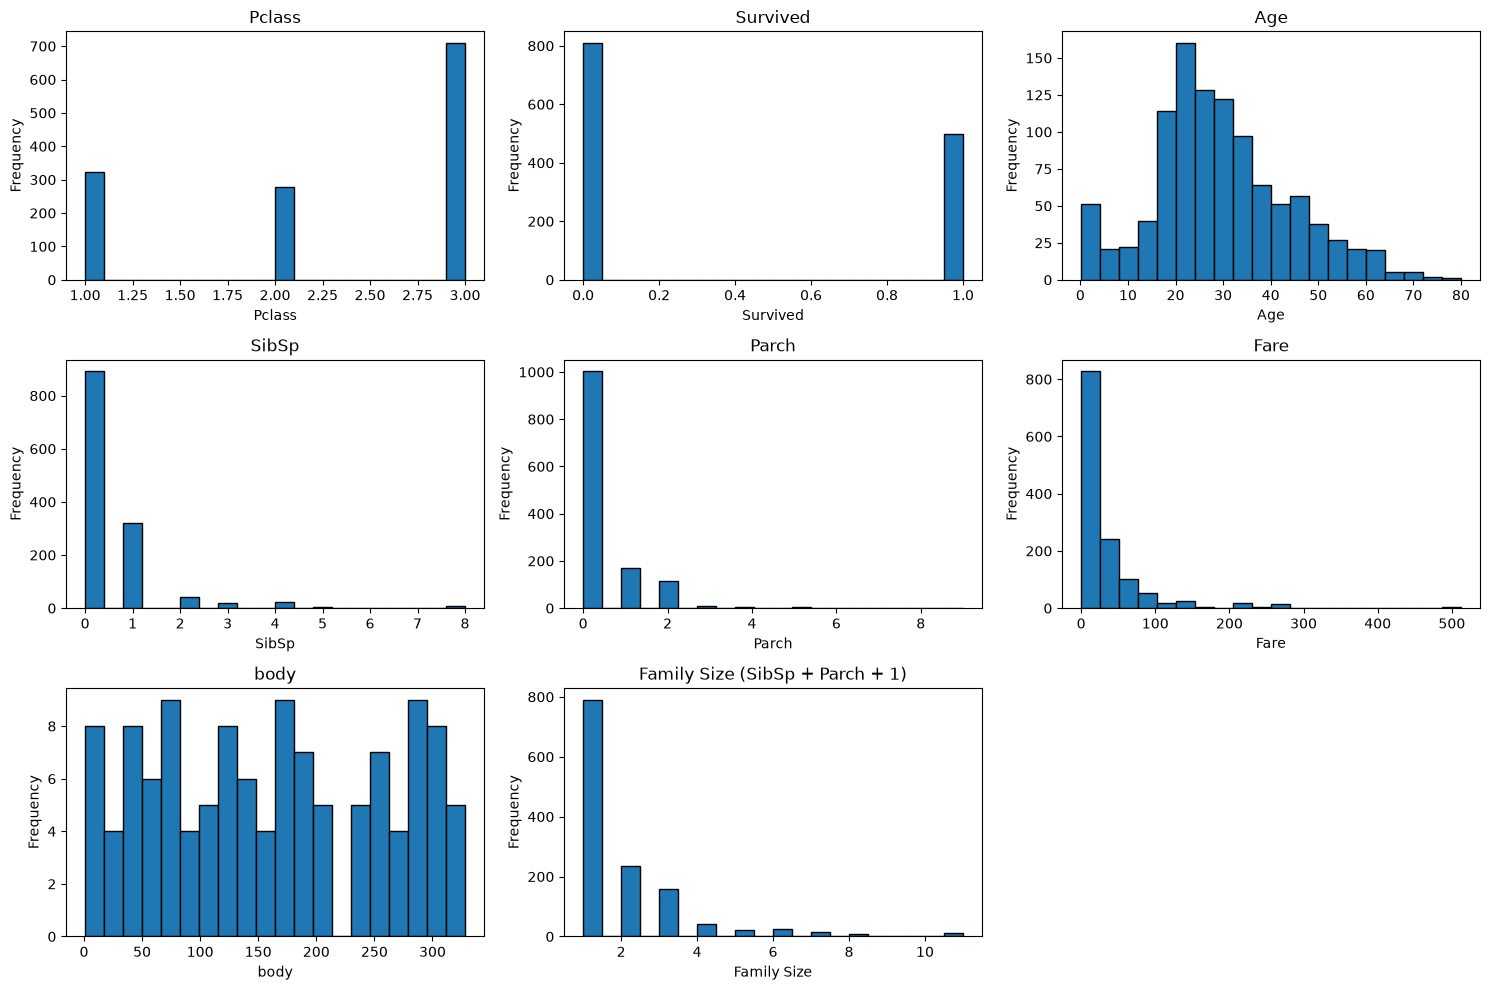

In [22]:
num_cols = df.select_dtypes(include=["number"]).columns

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 10)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

axes[len(num_cols)].hist(df['SibSp'] + df['Parch'] + 1, bins=20, edgecolor="black")
axes[len(num_cols)].set_title("Family Size (SibSp + Parch + 1)")
axes[len(num_cols)].set_xlabel("Family Size")
axes[len(num_cols)].set_ylabel("Frequency")

for i in range(len(num_cols)+1, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [23]:
df.columns

Index(['Pclass', 'Survived', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked', 'boat', 'body', 'home.dest'],
      dtype='str')

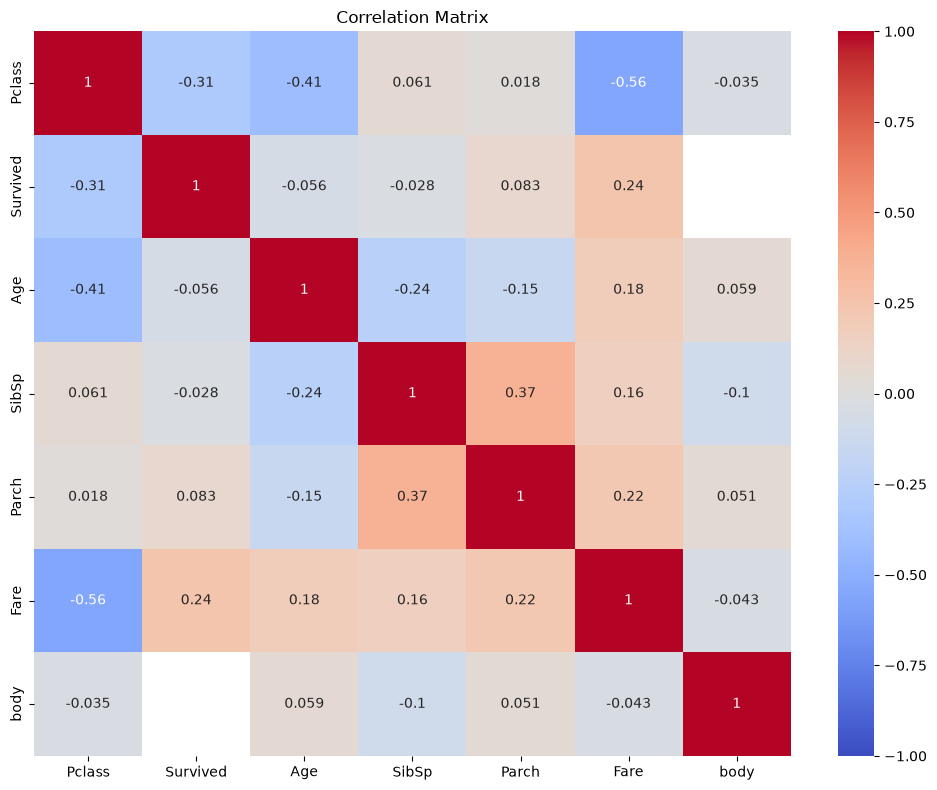

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,

)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Step 4: Decide, and write it down

For each column with a problem, add a markdown cell (or a row in a table here) saying
what you did and why. Code with no commentary earns much less credit than the same
code with one sentence of justification.

**Cleaning decisions:**


| Column | Decision | Why |
|--------|----------|-----|
| `boat` | **Drop** | assigned lifeboat almost only for survivors (**Near-perfect leakage**) |
| `body` | **Drop** | body identification numbers exist only for passengers who died. (**Perfect leakage**)|
| `home.dest` | **Drop** | High missingness (~43%), high cardinality(369 unique values), it is known afterwords so it is not a reliable pre-voyage predictor. |
| `Cabin` | Drop raw string and make a `has_cabin` feature | ~77% missing values so it is dropped but the presence of a cabin record predicts survival strongly (~65% vs ~30%). |
| `Name` | Drop raw text but make a `title` feature | more then name the title (Mr/Mrs/Miss/Master/Rare) is a more meaningful signal. |
| `Ticket` | **Drop** | It is dropped because of the high cardinality (929 unique values) and the information encoded in it can be evaluated from other features. |
| `Age` | Keep; median-impute in pipeline | ~20% missing values. The missingness predicts survival, so imputing values is better then just dropping the column. Median is robust to the long tail so imputation will be median based. |
| `Embarked` | Keep; most-frequent impute in pipeline | Only 2 missing rows, so mode is a safe fill. |
| `Fare` | Keep median-impute (1 missing) and  zeros left as-is | 17 zeros — likely crew/complimentary, not a placeholder for null. |
| `Sex` | Keep as-is | No quality issues. It will be treated as a categorical feature.|
| `Pclass` | Keep as-is | No quality issues. It will be treated as a categorical feature. |
| `SibSp` | Keep as-is | No quality issues. It will be treated as a count.|
| `Parch` | Keep as-is | No quality issues. It will be treated as a count.|
| `Survived` | Target only | Never used as a feature. |


In [25]:
# # The following command extracts the title from the "Name" column and creates a new column called "title". It then drops unnecessary columns and prints the remaining columns and the shape of the cleaned DataFrame.
# df["title"] = df["Name"].str.extract(r",\s*([^.]*)\.")
# df['has_cabin'] = df['Cabin'].notna().astype(int)
# df_clean = df.drop(columns=["boat", "body", "home.dest", "Ticket"]).copy()
# print("Columns after cleaning are the following:")
# print(df_clean.columns.to_list())
# print()
# print('The shape of the cleaned DataFrame is:')
# print(df_clean.shape)

## Step 5: Split first, before fitting anything (`pipeline.py`)

In [26]:
# TODO: build X (drop the target and any obvious identifiers/free text you won't
# use directly) and y, then train_test_split with stratify=y and a fixed random_state.
# Nothing should be .fit() on the full dataset before this split exists.

X = df.drop(columns=["Survived", "boat", "body", "home.dest", "Ticket"])
y = df["Survived"].astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("y_test balance:", y_test.value_counts(normalize=True).round(3).to_dict())

X_train: (1047, 9) X_test: (262, 9)
y_train balance: {0: 0.618, 1: 0.382}
y_test balance: {0: 0.618, 1: 0.382}


## Step 6: Column groups - and check them by eye

In [27]:
# TODO: split X's columns into numeric vs categorical. Print both lists and look at
# them - does anything dtype-based selection picked up actually belong in the other
# group? (Think about what Pclass really represents.)

num_cols_raw = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols_raw = X_train.select_dtypes(exclude=["number"]).columns.tolist()
print("dtype numeric:", num_cols_raw)
print("dtype categorical:", cat_cols_raw)
print()
print("NOTE: Pclass is integer-coded but ordinal/categorical in meaning.")
print("      It must NOT be scaled as a continuous numeric feature.")
print("      After feature engineering (Day 2) we force Pclass into cat_cols.")

dtype numeric: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
dtype categorical: ['Name', 'Sex', 'Cabin', 'Embarked']

NOTE: Pclass is integer-coded but ordinal/categorical in meaning.
      It must NOT be scaled as a continuous numeric feature.
      After feature engineering (Day 2) we force Pclass into cat_cols.


In [29]:
# Persist split for Day 2 — do not re-split with a different random_state
joblib.dump(
    {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "source": source,
    },
    "split.joblib",
)
print("Saved split.joblib")

Saved split.joblib


---
**Before you close this notebook today:**
- Save your split so Day 2 resumes rather than re-derives it - e.g.
  `joblib.dump({"X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test}, "split.joblib")`.
  Re-splitting tomorrow with a different `random_state` would silently invalidate every
  comparison you make against today's work.
- Confirm your split used `stratify=y` and a fixed `random_state`.
- Make sure Step 4's cleaning decisions are actually written down while the reasoning
  is fresh - reconstructing it tomorrow produces visibly thinner justifications.
- Keep this notebook and folder as-is. Day 2 is a new notebook here, not a restart.